# BÀI TẬP THỰC HÀNH K-NEAREST NEIGHBORS (K-NN)

## PHẦN 1: CƠ SỞ TOÁN HỌC & CHIẾN LƯỢC XỬ LÝ ĐỒNG HẠNG (TIE-BREAKING)

### 1.1. Công thức tính khoảng cách
1. **Khoảng cách Euclidean ($L_2$):**
   $$d_E(P, Q) = \sqrt{(x_P - x_Q)^2 + (y_P - y_Q)^2}$$
2. **Khoảng cách Manhattan ($L_1$):**
   $$d_M(P, Q) = |x_P - x_Q| + |y_P - y_Q|$$

---

### 1.2. Thuật toán K-NN & Quy tắc bỏ phiếu
1. Tính khoảng cách $d(P, X_i)$ tới 31 điểm huấn luyện.
2. Sắp xếp khoảng cách tăng dần: $d_{(1)} \le d_{(2)} \le \dots \le d_{(k)}$.
3. Chọn $k$ lân cận gần nhất: $N_k(P)$.
4. Bỏ phiếu đa số (Majority Voting):
   $$\hat{y}(P) = \arg\max_{c \in C} \sum_{i=1}^k \mathbb{I}(y_{(i)} = c)$$

---

### 1.3. Quy tắc giải quyết bằng nhau (Tie-Breaking) ngắn gọn

#### A. Hòa khoảng cách ở biên $k$ (Distance Tie):
1. **Dùng khoảng cách phụ (Metric Fallback):** Với Manhattan, dùng Euclidean làm tiêu chí phụ (chọn điểm có đường thẳng $d_E$ ngắn hơn).
2. **Cùng lớp (Same-Class Invariance):** Nếu các điểm hòa cùng thuộc một lớp $\to$ bất biến số phiếu, chọn điểm bất kỳ.
3. **Đối xứng trục:** Nếu bằng nhau ở cả 2 độ đo, sắp xếp theo ID để đảm bảo tính tất định.

#### B. Hòa số phiếu bầu (Vote Tie):
1. **Tổng khoảng cách nhỏ nhất (Mật độ cục bộ):** Lớp có tổng khoảng cách $\sum d$ nhỏ hơn sẽ thắng.
2. **Lân cận gần nhất (1-NN):** Nếu tổng khoảng cách bằng nhau, lớp có điểm gần nhất ($\min d$) thắng.


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

train_data = {
    # Red Triangle (8 điểm)
    'R1': {'coord': (1, 9), 'class': 'Red Triangle', 'color': '#E63946', 'marker': '^'},
    'R2': {'coord': (3, 9), 'class': 'Red Triangle', 'color': '#E63946', 'marker': '^'},
    'R3': {'coord': (4, 7), 'class': 'Red Triangle', 'color': '#E63946', 'marker': '^'},
    'R4': {'coord': (6, 5), 'class': 'Red Triangle', 'color': '#E63946', 'marker': '^'},
    'R5': {'coord': (2, 4), 'class': 'Red Triangle', 'color': '#E63946', 'marker': '^'},
    'R6': {'coord': (1, 2), 'class': 'Red Triangle', 'color': '#E63946', 'marker': '^'},
    'R7': {'coord': (6, 2), 'class': 'Red Triangle', 'color': '#E63946', 'marker': '^'},
    'R8': {'coord': (3, 1), 'class': 'Red Triangle', 'color': '#E63946', 'marker': '^'},

    # Blue Square (9 điểm)
    'B1': {'coord': (9, 9), 'class': 'Blue Square', 'color': '#1D3557', 'marker': 's'},
    'B2': {'coord': (7, 8), 'class': 'Blue Square', 'color': '#1D3557', 'marker': 's'},
    'B3': {'coord': (1, 7), 'class': 'Blue Square', 'color': '#1D3557', 'marker': 's'},
    'B4': {'coord': (3, 7), 'class': 'Blue Square', 'color': '#1D3557', 'marker': 's'},
    'B5': {'coord': (8, 5), 'class': 'Blue Square', 'color': '#1D3557', 'marker': 's'},
    'B6': {'coord': (5, 3), 'class': 'Blue Square', 'color': '#1D3557', 'marker': 's'},
    'B7': {'coord': (8, 3), 'class': 'Blue Square', 'color': '#1D3557', 'marker': 's'},
    'B8': {'coord': (9, 2), 'class': 'Blue Square', 'color': '#1D3557', 'marker': 's'},
    'B9': {'coord': (8, 1), 'class': 'Blue Square', 'color': '#1D3557', 'marker': 's'},

    # Green Star (5 điểm)
    'G1': {'coord': (4, 8), 'class': 'Green Star', 'color': '#2A9D8F', 'marker': '*'},
    'G2': {'coord': (8, 7), 'class': 'Green Star', 'color': '#2A9D8F', 'marker': '*'},
    'G3': {'coord': (4, 4), 'class': 'Green Star', 'color': '#2A9D8F', 'marker': '*'},
    'G4': {'coord': (8, 2), 'class': 'Green Star', 'color': '#2A9D8F', 'marker': '*'},
    'G5': {'coord': (2, 1), 'class': 'Green Star', 'color': '#2A9D8F', 'marker': '*'},

    # Black Heart (9 điểm)
    'H1': {'coord': (2, 5), 'class': 'Black Heart', 'color': '#2B2D42', 'marker': 'v'},
    'H2': {'coord': (3, 5), 'class': 'Black Heart', 'color': '#2B2D42', 'marker': 'v'},
    'H3': {'coord': (4, 5), 'class': 'Black Heart', 'color': '#2B2D42', 'marker': 'v'},
    'H4': {'coord': (1, 3), 'class': 'Black Heart', 'color': '#2B2D42', 'marker': 'v'},
    'H5': {'coord': (3, 3), 'class': 'Black Heart', 'color': '#2B2D42', 'marker': 'v'},
    'H6': {'coord': (2, 2), 'class': 'Black Heart', 'color': '#2B2D42', 'marker': 'v'},
    'H7': {'coord': (4, 2), 'class': 'Black Heart', 'color': '#2B2D42', 'marker': 'v'},
    'H8': {'coord': (1, 1), 'class': 'Black Heart', 'color': '#2B2D42', 'marker': 'v'},
    'H9': {'coord': (5, 1), 'class': 'Black Heart', 'color': '#2B2D42', 'marker': 'v'},
}

test_points = {
    'A': (2, 8),
    'B': (6, 7),
    'C': (7, 5),
    'D': (2, 3),
    'E': (7, 2),
    'F': (4, 1)
}

print(f"Tổng số điểm dữ liệu huấn luyện : {len(train_data)} điểm (4 lớp)")
print(f"Tổng số điểm truy vấn cần dự đoán : {len(test_points)} điểm (A -> F)")


Tổng số điểm dữ liệu huấn luyện : 31 điểm (4 lớp)
Tổng số điểm truy vấn cần dự đoán : 6 điểm (A -> F)


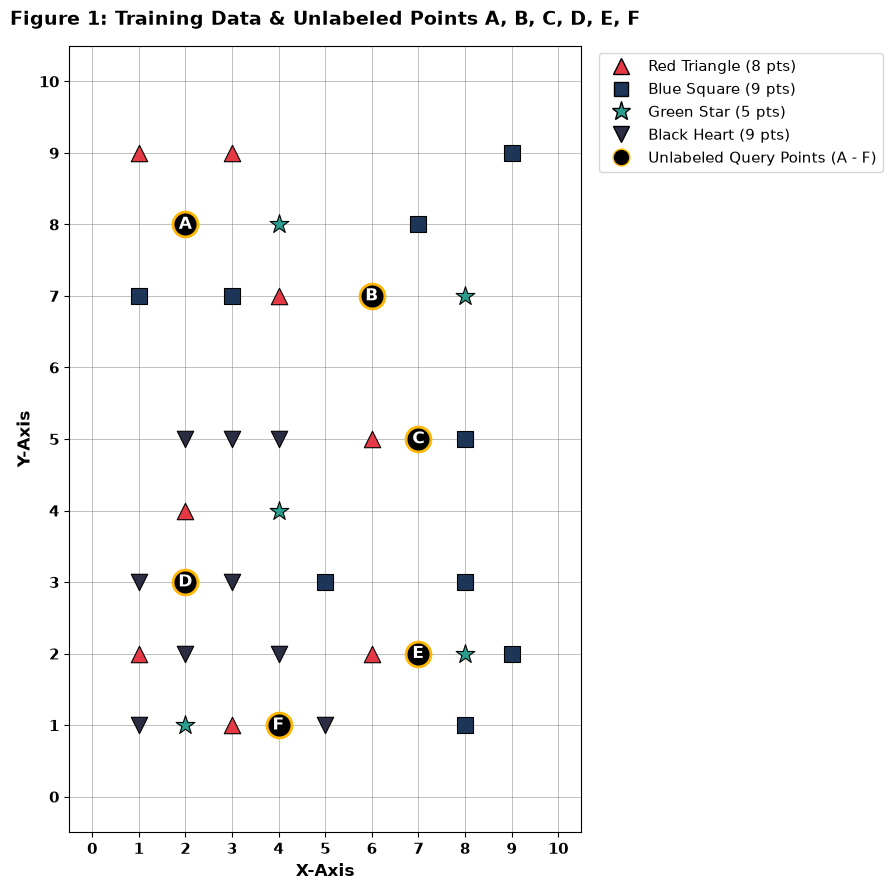

In [2]:
plt.figure(figsize=(9, 9), dpi=100)

for pid, d in train_data.items():
    plt.scatter(d['coord'][0], d['coord'][1], color=d['color'], marker=d['marker'], 
                s=140 if d['marker']!='*' else 200, edgecolors='black', linewidths=0.8, zorder=3)

for name, coord in test_points.items():
    plt.scatter(coord[0], coord[1], color='black', s=320, edgecolors='#FFB703', linewidths=2, zorder=4)
    plt.text(coord[0], coord[1], name, color='white', weight='bold', fontsize=12,
             ha='center', va='center', zorder=5)

plt.xlim(-0.5, 10.5)
plt.ylim(-0.5, 10.5)
plt.xticks(range(0, 11), fontsize=11, weight='bold')
plt.yticks(range(0, 11), fontsize=11, weight='bold')
plt.grid(True, which='both', color='gray', linestyle='-', linewidth=0.7, alpha=0.5)

legend_elements = [
    plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='#E63946', markeredgecolor='k', markersize=11, label='Red Triangle (8 pts)'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='#1D3557', markeredgecolor='k', markersize=10, label='Blue Square (9 pts)'),
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='#2A9D8F', markeredgecolor='k', markersize=14, label='Green Star (5 pts)'),
    plt.Line2D([0], [0], marker='v', color='w', markerfacecolor='#2B2D42', markeredgecolor='k', markersize=11, label='Black Heart (9 pts)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markeredgecolor='#FFB703', markersize=12, label='Unlabeled Query Points (A - F)')
]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=11, frameon=True)
plt.title('Figure 1: Training Data & Unlabeled Points A, B, C, D, E, F', fontsize=14, weight='bold', pad=15)
plt.xlabel('X-Axis', fontsize=12, weight='bold')
plt.ylabel('Y-Axis', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()


In [3]:
# BẢNG TÍNH TOÁN VÀ SẮP XẾP KHOẢNG CÁCH TỪ 1 ĐIỂM ĐẾN TOÀN BỘ 31 ĐIỂM DỮ LIỆU
def print_distances_to_all_points(target_name='A', sort_by='euclidean'):
    """
    Tính và in ra bảng khoảng cách từ 1 điểm truy vấn đến toàn bộ 31 điểm huấn luyện,
    sắp xếp thứ tự từ khoảng cách ngắn nhất đến dài nhất.
    """
    if target_name not in test_points:
        raise ValueError(f"Điểm {target_name} không hợp lệ! Hãy chọn một trong các điểm: {list(test_points.keys())}")
        
    target_coord = test_points[target_name]
    table_data = []
    for pid, info in train_data.items():
        coord = info['coord']
        d_euc = math.sqrt((target_coord[0] - coord[0])**2 + (target_coord[1] - coord[1])**2)
        d_man = abs(target_coord[0] - coord[0]) + abs(target_coord[1] - coord[1])
        table_data.append({
            'id': pid,
            'coord': coord,
            'class': info['class'],
            'dist_euc': d_euc,
            'dist_man': d_man
        })
        
    # Sắp xếp từ ngắn nhất đến dài nhất (mặc định theo Euclidean, hòa xét Manhattan rồi ID)
    if sort_by.lower() == 'euclidean':
        table_data.sort(key=lambda x: (round(x['dist_euc'], 6), round(x['dist_man'], 6), x['id']))
        sort_desc = "Euclidean (d_E tăng dần)"
    else:
        table_data.sort(key=lambda x: (round(x['dist_man'], 6), round(x['dist_euc'], 6), x['id']))
        sort_desc = "Manhattan (d_M tăng dần)"
        
    headers = ["Hạng", "ID", "Tọa độ", "Lớp dữ liệu", "KC Euclidean (d_E)", "KC Manhattan (d_M)"]
    rows = [
        [rank, item['id'], f"({item['coord'][0]}, {item['coord'][1]})", item['class'], f"{item['dist_euc']:.4f}", f"{item['dist_man']}"]
        for rank, item in enumerate(table_data, 1)
    ]
    
    print("=" * 85)
    print(f"BẢNG KHOẢNG CÁCH TỪ ĐIỂM {target_name} {target_coord} ĐẾN 31 ĐIỂM HUẤN LUYỆN (SẮP XẾP: {sort_desc.upper()})")
    print("=" * 85)
    print(tabulate(rows, headers=headers, tablefmt="grid"))

# In khoảng cách từ Điểm A (2, 8) đến toàn bộ 31 điểm (sắp xếp từ ngắn nhất đến dài nhất)
print_distances_to_all_points(target_name='A', sort_by='euclidean')


BẢNG KHOẢNG CÁCH TỪ ĐIỂM A (2, 8) ĐẾN 31 ĐIỂM HUẤN LUYỆN (SẮP XẾP: EUCLIDEAN (D_E TĂNG DẦN))
+--------+------+----------+---------------+----------------------+----------------------+
|   Hạng | ID   | Tọa độ   | Lớp dữ liệu   |   KC Euclidean (d_E) |   KC Manhattan (d_M) |
+========+======+==========+===============+======================+======================+
|      1 | B3   | (1, 7)   | Blue Square   |               1.4142 |                    2 |
+--------+------+----------+---------------+----------------------+----------------------+
|      2 | B4   | (3, 7)   | Blue Square   |               1.4142 |                    2 |
+--------+------+----------+---------------+----------------------+----------------------+
|      3 | R1   | (1, 9)   | Red Triangle  |               1.4142 |                    2 |
+--------+------+----------+---------------+----------------------+----------------------+
|      4 | R2   | (3, 9)   | Red Triangle  |               1.4142 |                    2

## PHẦN 2: CÂU (a) - BẢNG TÍNH TOÁN KHOẢNG CÁCH VÀ PHÂN LỚP TỪNG BƯỚC


---

### 1. ĐIỂM A $(2, 8)$
- **Euclidean:** R1, R2, B3, B4 ($d=\sqrt{2}\approx 1.41$); G1 ($d=2.0$); R3 ($d=\sqrt{5}\approx 2.24$); H1 ($d=3.0$).
- **Manhattan:** R1, R2, B3, B4, G1 ($d=2$); R3, H1 ($d=3$).

| Cấu hình | $k$ Lân cận chọn | Phiếu bầu | Nhãn dự đoán | Note |
|---|---|---|:---:|---|
| **Euclidean, $k=4$** | R1, R2, B3, B4 | Red: 2, Blue: 2 | **TIE: Red / Blue** | Hòa phiếu 2-2 (4 điểm đối xứng cùng $d=1.41$) |
| **Euclidean, $k=5$** | 4 điểm trên + G1 | Red: 2, Blue: 2, Green: 1 | **TIE: Red / Blue** | Hòa phiếu 2-2 (G1 thêm vào không đổi thế hòa) |
| **Euclidean, $k=6$** | 5 điểm trên + R3 | **Red: 3**, Blue: 2, Green: 1 | **Red Triangle** | - |
| **Manhattan, $k=4$** | R1, R2, B3, B4 | Red: 2, Blue: 2 | **TIE: Red / Blue** | Hòa KC $d_M=2$ (5 điểm): Chọn 4 điểm có $d_E=1.41 < 2.0$; Hòa phiếu 2-2 |
| **Manhattan, $k=5$** | R1, R2, B3, B4, G1 | Red: 2, Blue: 2, Green: 1 | **TIE: Red / Blue** | Hòa phiếu 2-2 (chọn trọn vẹn 5 điểm $d_M=2$) |
| **Manhattan, $k=6$** | 5 điểm trên + R3 | **Red: 3**, Blue: 2, Green: 1 | **Red Triangle** | Hòa KC $d_M=3$ (R3, H1): Chọn R3 vì $d_E=2.24 < 3.0$ |

---

### 2. ĐIỂM B $(6, 7)$
- **Euclidean:** B2 ($1.41$); R3, R4, G2 ($2.0$); G1 ($2.24$); H3, B5 ($2.83$).
- **Manhattan:** B2, R3, R4, G2 ($2$); G1, B4 ($3$); B5, H3 ($4$).

| Cấu hình | $k$ Lân cận chọn | Phiếu bầu | Nhãn dự đoán | Note |
|---|---|---|:---:|---|
| **Euclidean, $k=4$** | B2, R3, R4, G2 | **Red: 2**, Blue: 1, Green: 1 | **Red Triangle** | - |
| **Euclidean, $k=5$** | 4 điểm trên + G1 | **Red: 2, Green: 2**, Blue: 1 | **Red Triangle** | Hòa phiếu 2-2: Chọn Red (tổng KC $4.0 < 4.24$) |
| **Euclidean, $k=6$** | 5 điểm trên + B5 | **Red: 2**, Green: 2, Blue: 2 | **Red Triangle** | Hòa KC $d_E=2.83$ (B5, H3); Hòa phiếu: Chọn Red (tổng KC min) |
| **Manhattan, $k=4$** | B2, R3, R4, G2 | **Red: 2**, Blue: 1, Green: 1 | **Red Triangle** | - |
| **Manhattan, $k=5$** | 4 điểm trên + G1 | **Red: 2, Green: 2**, Blue: 1 | **Red Triangle** | Hòa KC $d_M=3$: Chọn G1 ($d_E=2.24 < 3.0$); Hòa phiếu: Chọn Red |
| **Manhattan, $k=6$** | 4 điểm trên + G1 + B4 | **Red: 2**, Green: 2, Blue: 2 | **Red Triangle** | Hòa phiếu 2-2-2: Chọn Red (tổng KC min: Red=4, Green=5, Blue=5) |

---

### 3. ĐIỂM C $(7, 5)$
- **Euclidean:** R4, B5 ($1.0$); B7, G2 ($2.24$); B6 ($2.83$); H3, B2 ($3.0$).
- **Manhattan:** R4, B5 ($1$); B7, H3, G2, B2 ($3$); B6 ($4$).

| Cấu hình | $k$ Lân cận chọn | Phiếu bầu | Nhãn dự đoán | Note |
|---|---|---|:---:|---|
| **Euclidean, $k=4$** | R4, B5, B7, G2 | **Blue: 2**, Red: 1, Green: 1 | **Blue Square** | - |
| **Euclidean, $k=5$** | 4 điểm trên + B6 | **Blue: 3**, Red: 1, Green: 1 | **Blue Square** | - |
| **Euclidean, $k=6$** | 5 điểm trên + B2 | **Blue: 4**, Red: 1, Green: 1 | **Blue Square** | Hòa KC $d_E=3.0$ (B2, H3): Blue luôn thắng áp đảo |
| **Manhattan, $k=4$** | R4, B5, B7, G2 | **Blue: 2**, Red: 1, Green: 1 | **Blue Square** | Hòa KC $d_M=3$ (4 điểm): Chọn B7, G2 vì $d_E=2.24 < 3.0$ |
| **Manhattan, $k=5$** | R4, B5, B7, G2, B2 | **Blue: 3**, Red: 1, Green: 1 | **Blue Square** | Hòa KC $d_M=3$: Chọn thêm B2, Blue luôn giữ đa số |
| **Manhattan, $k=6$** | R4, B5, B7, G2, H3, B2 | **Blue: 3**, Red: 1, Green: 1, Black: 1 | **Blue Square** | - |

---

### 4. ĐIỂM D $(2, 3)$
- **Euclidean:** R5, H6, H5, H4 ($1.0$); R6 ($1.41$); G5, H1 ($2.0$).
- **Manhattan:** R5, H6, H5, H4 ($1$); G5, H1, R6 ($2$).

| Cấu hình | $k$ Lân cận chọn | Phiếu bầu | Nhãn dự đoán | Note |
|---|---|---|:---:|---|
| **Euclidean, $k=4$** | R5, H6, H5, H4 | **Black: 3**, Red: 1 | **Black Heart** | - |
| **Euclidean, $k=5$** | 4 điểm trên + R6 | **Black: 3**, Red: 2 | **Black Heart** | - |
| **Euclidean, $k=6$** | 5 điểm trên + G5 | **Black: 3**, Red: 2, Green: 1 | **Black Heart** | Hòa KC $d_E=2.0$ (G5, H1): Black luôn thắng |
| **Manhattan, $k=4$** | R5, H6, H5, H4 | **Black: 3**, Red: 1 | **Black Heart** | - |
| **Manhattan, $k=5$** | 4 điểm trên + R6 | **Black: 3**, Red: 2 | **Black Heart** | Hòa KC $d_M=2$ (3 điểm): Chọn R6 vì $d_E=1.41 < 2.0$ |
| **Manhattan, $k=6$** | 4 điểm trên + R6 + G5 | **Black: 3**, Red: 2, Green: 1 | **Black Heart** | Hòa KC $d_M=2$: Black Heart duy trì đa số |

---

### 5. ĐIỂM E $(7, 2)$
- **Euclidean:** G4, R7 ($1.0$); B7, B9 ($1.41$); B8 ($2.0$); B6, H9 ($2.24$).
- **Manhattan:** G4, R7 ($1$); B7, B9, B8 ($2$); B6, H9, H7 ($3$).

| Cấu hình | $k$ Lân cận chọn | Phiếu bầu | Nhãn dự đoán | Note |
|---|---|---|:---:|---|
| **Euclidean, $k=4$** | G4, R7, B7, B9 | **Blue: 2**, Green: 1, Red: 1 | **Blue Square** | - |
| **Euclidean, $k=5$** | 4 điểm trên + B8 | **Blue: 3**, Green: 1, Red: 1 | **Blue Square** | - |
| **Euclidean, $k=6$** | 5 điểm trên + B6 | **Blue: 4**, Green: 1, Red: 1 | **Blue Square** | Hòa KC $d_E=2.24$ (B6, H9): Blue luôn thắng áp đảo |
| **Manhattan, $k=4$** | G4, R7, B7, B9 | **Blue: 2**, Green: 1, Red: 1 | **Blue Square** | Hòa KC $d_M=2$ (3 điểm): Cùng lớp Blue (bất biến); ưu tiên B7, B9 vì $d_E=1.41 < 2.0$ |
| **Manhattan, $k=5$** | G4, R7, B7, B9, B8 | **Blue: 3**, Green: 1, Red: 1 | **Blue Square** | - |
| **Manhattan, $k=6$** | 5 điểm trên + B6 | **Blue: 4**, Green: 1, Red: 1 | **Blue Square** | Hòa KC $d_M=3$ (3 điểm): Chọn B6 vì $d_E=2.24 < 3.0$ |

---

### 6. ĐIỂM F $(4, 1)$
- **Euclidean:** H9, H7, R8 ($1.0$); G5 ($2.0$); H6, B6, R7, H5 ($2.24$).
- **Manhattan:** H9, H7, R8 ($1$); G5 ($2$); H8, B6, G3, H5, H6, R7 ($3$).

| Cấu hình | $k$ Lân cận chọn | Phiếu bầu | Nhãn dự đoán | Note |
|---|---|---|:---:|---|
| **Euclidean, $k=4$** | H9, H7, R8, G5 | **Black: 2**, Red: 1, Green: 1 | **Black Heart** | - |
| **Euclidean, $k=5$** | 4 điểm trên + B6 | **Black: 2**, Red: 1, Green: 1, Blue: 1 | **Black Heart** | Hòa KC $d_E=2.24$ (4 điểm): Black luôn dẫn đầu |
| **Euclidean, $k=6$** | 4 điểm trên + B6 + H5 | **Black: 3**, Red: 1, Green: 1, Blue: 1 | **Black Heart** | Hòa KC $d_E=2.24$: Black củng cố đa số |
| **Manhattan, $k=4$** | H9, H7, R8, G5 | **Black: 2**, Red: 1, Green: 1 | **Black Heart** | - |
| **Manhattan, $k=5$** | 4 điểm trên + B6 | **Black: 2**, Red: 1, Green: 1, Blue: 1 | **Black Heart** | Hòa KC $d_M=3$ (6 điểm): Ưu tiên nhóm có $d_E=2.24 < 3.0$ |
| **Manhattan, $k=6$** | 4 điểm trên + B6 + H5 | **Black: 3**, Red: 1, Green: 1, Blue: 1 | **Black Heart** | Hòa KC $d_M=3$: Black Heart tiếp tục dẫn đầu |

## PHẦN 3: CÂU (b) - PHÂN TÍCH SO SÁNH TOÀN DIỆN

### Bảng Tổng hợp Kết quả:

| Điểm | Tọa độ | Euc ($k=4$) | Euc ($k=5$) | Euc ($k=6$) | Man ($k=4$) | Man ($k=5$) | Man ($k=6$) | Note |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|---|
| **A** | $(2, 8)$ | Tie (Red/Blue) | Tie (Red/Blue) | **Red Triangle** | Tie (Red/Blue) | Tie (Red/Blue) | **Red Triangle** | Vùng biên đối xứng; chuyển sang **Red** khi $k=6$ |
| **B** | $(6, 7)$ | **Red Triangle** | Tie (Red/Green)* | **Red Triangle** | **Red Triangle** | Tie (Red/Green)* | **Red Triangle** | Xu hướng **Red** áp đảo (phá hòa bằng $\min \sum d$) |
| **C** | $(7, 5)$ | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** | **Ổn định tuyệt đối 100%** |
| **D** | $(2, 3)$ | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** | **Ổn định tuyệt đối 100%** |
| **E** | $(7, 2)$ | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** | **Blue Square** | **Ổn định tuyệt đối 100%** |
| **F** | $(4, 1)$ | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** | **Black Heart** | **Ổn định tuyệt đối 100%** |

---

### 1. Tác động của tham số $k$ ($k = 4, 5, 6$):
- **Hiệu ứng chẵn/lẻ:** $k$ chẵn ($4, 6$) dễ hòa phiếu đối xứng ($2-2$ tại A); $k=5$ lẻ vẫn có thể hòa trong bài toán 4 lớp ($2-2-1$ tại B).
- **Mở rộng bán kính:** $k$ nhỏ chú trọng điểm cực gần; $k$ lớn bao quát mật độ cụm rộng hơn (giúp điểm A chuyển hẳn sang Red Triangle khi $k=6$).
- **Độ ổn định:** Các điểm nằm sâu trong cụm ($C, D, E, F$) không bị ảnh hưởng bởi thay đổi $k$.

---

### 2. Tác động của hàm khoảng cách (Euclidean vs. Manhattan):
- **Hình học đẳng cự:** Euclidean là hình tròn (bảo toàn góc quay); Manhattan là hình thoi $45^\circ$ (cộng dồn bước chéo $\Delta x + \Delta y$).
- **Tần suất hòa khoảng cách:** Manhattan trên lưới nguyên sinh ra nhiều điểm bằng khoảng cách hơn hẳn Euclidean.
- **Tính nhất quán:** Dù khác biệt về hình học, kết quả phân lớp cuối cùng giữa Euclidean và Manhattan hoàn toàn đồng nhất trên cả 6 điểm.


## PHẦN 4: CÂU (c) - CÀI ĐẶT THUẬT TOÁN K-NN


In [4]:
class KNNClassifierFromScratch:
    def __init__(self, train_data, test_points):
        self.train_data = train_data
        self.test_points = test_points
        
    @staticmethod
    def euclidean_distance(p1, p2):
        return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)
    
    @staticmethod
    def manhattan_distance(p1, p2):
        return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])
    
    def predict_point(self, target_name, k, metric='euclidean', verbose=True):
        if target_name not in self.test_points:
            raise ValueError(f"Điểm {target_name} không hợp lệ!")
            
        target_coord = self.test_points[target_name]
        is_euc = (metric.lower() == 'euclidean')
        prim_dist = self.euclidean_distance if is_euc else self.manhattan_distance
        sec_dist = self.manhattan_distance if is_euc else self.euclidean_distance
        sec_name = 'Manhattan' if is_euc else 'Euclidean'
        
        # 1. Tính khoảng cách tới 31 điểm
        records = []
        for pid, info in self.train_data.items():
            records.append({
                'id': pid,
                'coord': info['coord'],
                'class': info['class'],
                'dist': prim_dist(target_coord, info['coord']),
                'sec_dist': sec_dist(target_coord, info['coord'])
            })
            
        # 2. Sắp xếp: prim_dist -> sec_dist -> id
        records.sort(key=lambda x: (round(x['dist'], 6), round(x['sec_dist'], 6), x['id']))
        
        # 3. Kiểm tra Distance Tie ở biên k
        kth_d = records[k - 1]['dist']
        strictly_closer = [p for p in records if p['dist'] < kth_d - 1e-6]
        tied_at_k = [p for p in records if abs(p['dist'] - kth_d) < 1e-6]
        needed = k - len(strictly_closer)
        has_dist_tie = len(tied_at_k) > needed
        
        # 4. Tập k lân cận
        selected = records[:k]
        
        # 5. Đếm phiếu và tính tổng khoảng cách
        votes, dist_sums, min_dists = {}, {}, {}
        for p in selected:
            c = p['class']
            votes[c] = votes.get(c, 0) + 1
            dist_sums[c] = dist_sums.get(c, 0.0) + p['dist']
            if c not in min_dists or p['dist'] < min_dists[c]:
                min_dists[c] = p['dist']
                
        max_v = max(votes.values())
        top_c = [c for c, v in votes.items() if v == max_v]
        
        tie_notes = []
        short_note = "-"
        
        if has_dist_tie:
            tied_classes = set(p['class'] for p in tied_at_k)
            if len(tied_classes) == 1:
                tie_notes.append(f"Hòa KC d={kth_d:.2f} ({len(tied_at_k)} điểm cùng lớp {list(tied_classes)[0]}, bất biến nhãn)")
                short_note = f"Hòa KC d={kth_d:.2f} (cùng lớp {list(tied_classes)[0]})"
            else:
                tie_notes.append(f"Hòa KC d={kth_d:.2f} ({len(tied_at_k)} điểm), ưu tiên điểm có {sec_name} ngắn hơn")
                short_note = f"Hòa KC d={kth_d:.2f}, phá hòa bằng {sec_name}"
                
        if len(top_c) == 1:
            final_pred = top_c[0]
        else:
            final_pred = min(top_c, key=lambda c: (dist_sums[c], min_dists[c]))
            tie_notes.append(f"Hòa phiếu {max_v} đều giữa {top_c} -> Chọn {final_pred} (tổng KC = {dist_sums[final_pred]:.2f})")
            if short_note == "-":
                short_note = f"Hòa phiếu {max_v} đều: Chọn {final_pred} (tổng KC min)"
            else:
                short_note += f"; Hòa phiếu: Chọn {final_pred}"
                
        if verbose:
            print("=" * 85)
            print(f"BÁO CÁO K-NN - ĐIỂM {target_name} {target_coord} | k = {k} | Metric = {metric.upper()}")
            print("=" * 85)
            
            cand_headers = ["Hạng", "ID", "Tọa độ", "Lớp dữ liệu", f"KC ({metric.capitalize()})", f"KC ({sec_name})", "Chọn?"]
            cand_rows = []
            for rank, p in enumerate(records[:max(k+4, 10)], 1):
                is_sel = "CHỌN" if rank <= k else "-"
                cand_rows.append([rank, p['id'], f"({p['coord'][0]},{p['coord'][1]})", p['class'], f"{p['dist']:.4f}", f"{p['sec_dist']:.4f}", is_sel])
            print("\n1. BẢNG ỨNG VIÊN LÂN CẬN:")
            print(tabulate(cand_rows, headers=cand_headers, tablefmt="grid"))
            
            sel_headers = ["#", "ID", "Tọa độ", "Lớp dữ liệu", "Khoảng cách"]
            sel_rows = [[i+1, p['id'], p['coord'], p['class'], f"{p['dist']:.4f}"] for i, p in enumerate(selected)]
            print(f"\n2. TẬP {k} LÂN CẬN ĐƯỢC CHỌN:")
            print(tabulate(sel_rows, headers=sel_headers, tablefmt="psql"))
            
            vote_headers = ["Lớp dữ liệu", "Phiếu bầu", "Tỷ lệ (%)", "Tổng khoảng cách"]
            vote_rows = [[c, votes[c], f"{(votes[c]/k)*100:.1f}%", f"{dist_sums[c]:.4f}"] for c in sorted(votes.keys())]
            print("\n3. PHÂN BỐ PHIẾU BẦU:")
            print(tabulate(vote_rows, headers=vote_headers, tablefmt="grid"))
            
            print("\n4. GHI CHÚ XỬ LÝ ĐỒNG HẠNG (TIE-BREAKING):")
            if tie_notes:
                for n in tie_notes:
                    print(f" -> {n}")
            else:
                print(" -> Không có hòa. Thắng đa số rõ ràng.")
                
            print(f"\n>>> DỰ ĐOÁN CUỐI CÙNG: [ {final_pred.upper()} ]")
            print("=" * 85 + "\n")
            
        return {
            'target': target_name,
            'coord': target_coord,
            'k': k,
            'metric': metric,
            'selected_neighbors': selected,
            'votes': votes,
            'dist_sums': dist_sums,
            'prediction': final_pred,
            'note': short_note
        }

knn_model = KNNClassifierFromScratch(train_data, test_points)
print("Khởi tạo KNNClassifierFromScratch thành công!")

Khởi tạo KNNClassifierFromScratch thành công!


### ĐIỂM E VỚI $k=5$ (EUCLIDEAN VÀ MANHATTAN)

In [5]:
# 1. Điểm E với k = 5 theo Khoảng cách EUCLIDEAN
res_e_euclidean = knn_model.predict_point(target_name='E', k=5, metric='euclidean', verbose=True)

# 2. Điểm E với k = 5 theo Khoảng cách MANHATTAN
res_e_manhattan = knn_model.predict_point(target_name='E', k=5, metric='manhattan', verbose=True)


BÁO CÁO K-NN - ĐIỂM E (7, 2) | k = 5 | Metric = EUCLIDEAN

1. BẢNG ỨNG VIÊN LÂN CẬN:
+--------+------+----------+---------------+------------------+------------------+---------+
|   Hạng | ID   | Tọa độ   | Lớp dữ liệu   |   KC (Euclidean) |   KC (Manhattan) | Chọn?   |
+========+======+==========+===============+==================+==================+=========+
|      1 | G4   | (8,2)    | Green Star    |           1      |                1 | CHỌN    |
+--------+------+----------+---------------+------------------+------------------+---------+
|      2 | R7   | (6,2)    | Red Triangle  |           1      |                1 | CHỌN    |
+--------+------+----------+---------------+------------------+------------------+---------+
|      3 | B7   | (8,3)    | Blue Square   |           1.4142 |                2 | CHỌN    |
+--------+------+----------+---------------+------------------+------------------+---------+
|      4 | B9   | (8,1)    | Blue Square   |           1.4142 |               

### THỰC THI ĐẦY ĐỦ TẤT CẢ 6 ĐIỂM (A -> F) QUA TOÀN BỘ 6 CẤU HÌNH
Tự động chạy toàn bộ 36 kịch bản (6 điểm truy vấn $\times$ 6 cấu hình thực nghiệm) và in bảng tổng hợp chi tiết ra màn hình terminal của Python. Cột **Note** được đặt ở cột cuối cùng và chỉ ghi chú khi có tình trạng hòa khoảng cách hoặc hòa phiếu bầu.


In [6]:
all_results = []
metrics = ['euclidean', 'manhattan']
k_values = [4, 5, 6]
test_names = ['A', 'B', 'C', 'D', 'E', 'F']

print("BẮT ĐẦU CHẠY BATCH TOÀN BỘ CÁC CẤU HÌNH CHO TẤT CẢ CÁC ĐIỂM:")
for name in test_names:
    for metric in metrics:
        for k in k_values:
            res = knn_model.predict_point(target_name=name, k=k, metric=metric, verbose=False)
            all_results.append({
                'Điểm': name,
                'Tọa độ': str(res['coord']),
                'Hàm KC': metric.capitalize(),
                'k': k,
                'Lân cận chọn': ", ".join([p['id'] for p in res['selected_neighbors']]),
                'Phiếu bầu': ", ".join([f"{c}: {v}" for c, v in res['votes'].items()]),
                'Nhãn dự đoán': res['prediction'],
                'Note': res['note']  
            })

df_all_results = pd.DataFrame(all_results)
print("\nBẢNG TỔNG HỢP TOÀN BỘ 36 KẾT QUẢ PHÂN LỚP:")
print(tabulate(df_all_results, headers='keys', tablefmt='psql', showindex=False))


BẮT ĐẦU CHẠY BATCH TOÀN BỘ CÁC CẤU HÌNH CHO TẤT CẢ CÁC ĐIỂM:

BẢNG TỔNG HỢP TOÀN BỘ 36 KẾT QUẢ PHÂN LỚP:
+--------+----------+-----------+-----+------------------------+----------------------------------------------------------------+----------------+---------------------------------------------------------------------+
| Điểm   | Tọa độ   | Hàm KC    |   k | Lân cận chọn           | Phiếu bầu                                                      | Nhãn dự đoán   | Note                                                                |
|--------+----------+-----------+-----+------------------------+----------------------------------------------------------------+----------------+---------------------------------------------------------------------|
| A      | (2, 8)   | Euclidean |   4 | B3, B4, R1, R2         | Blue Square: 2, Red Triangle: 2                                | Blue Square    | Hòa phiếu 2 đều: Chọn Blue Square (tổng KC min)                     |
| A      | (2, 8)   | Eucli

## PHẦN 5: TRỰC QUAN HÓA HÌNH HỌC LÂN CẬN (NEIGHBORHOOD CONTOUR VISUALIZATION)
Trực quan hóa hình học vùng lân cận $k=5$ của Điểm $E(7, 2)$ để làm rõ sự khác biệt giữa hình tròn khoảng cách Euclidean và hình thoi khoảng cách Manhattan.


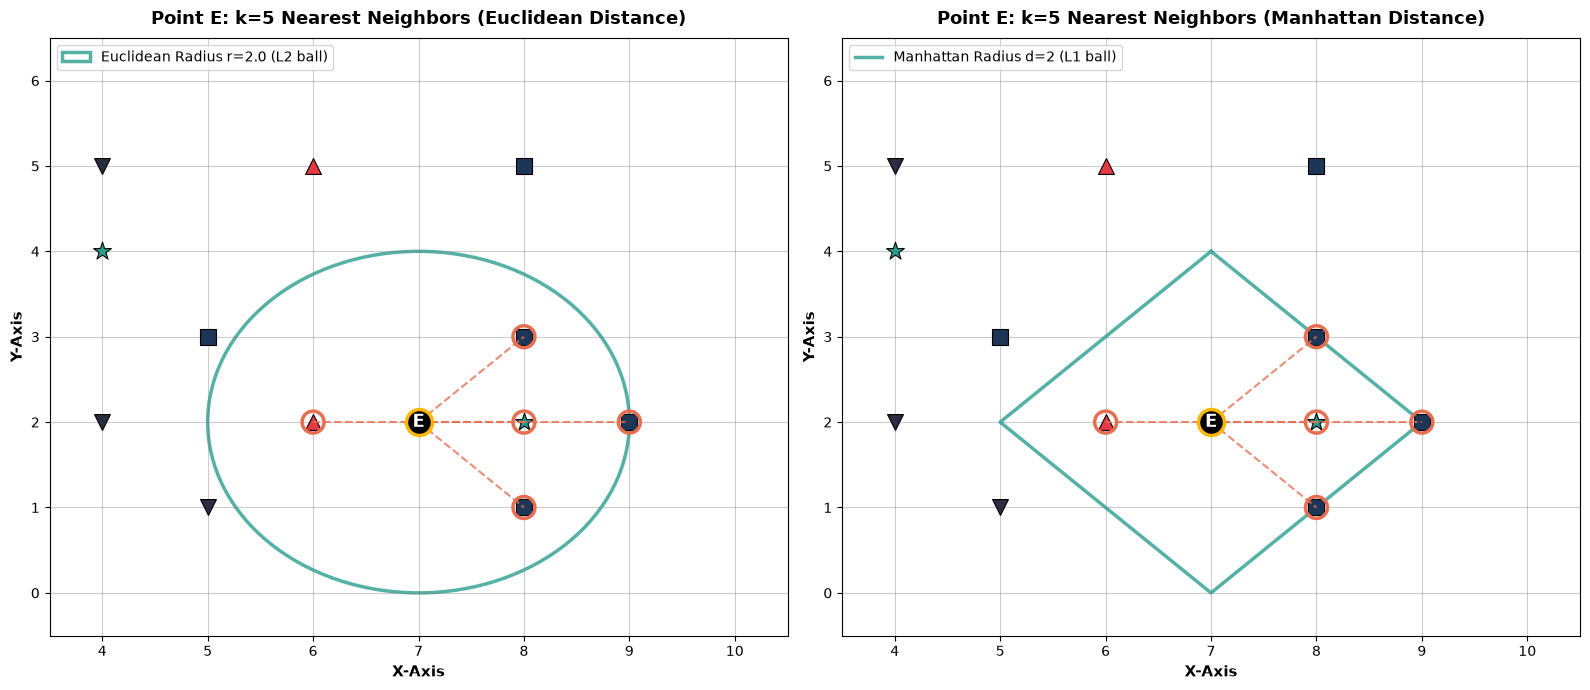

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)

for idx, (metric, ax) in enumerate(zip(['Euclidean', 'Manhattan'], axes)):
    for pid, d in train_data.items():
        ax.scatter(d['coord'][0], d['coord'][1], color=d['color'], marker=d['marker'], 
                   s=130 if d['marker']!='*' else 180, edgecolors='black', linewidths=0.8, zorder=3)
    
    e_coord = test_points['E']
    ax.scatter(e_coord[0], e_coord[1], color='black', s=350, edgecolors='#FFB703', linewidths=2.5, zorder=5)
    ax.text(e_coord[0], e_coord[1], 'E', color='white', weight='bold', fontsize=13, ha='center', va='center', zorder=6)
    
    res = knn_model.predict_point('E', k=5, metric=metric.lower(), verbose=False)
    for n in res['selected_neighbors']:
        ax.plot([e_coord[0], n['coord'][0]], [e_coord[1], n['coord'][1]], 
                color='#E76F51', linestyle='--', linewidth=1.5, alpha=0.8, zorder=4)
        ax.scatter(n['coord'][0], n['coord'][1], s=250, facecolors='none', edgecolors='#E76F51', linewidths=2.5, zorder=4)
        
    if metric == 'Euclidean':
        circle = plt.Circle(e_coord, 2.0, color='#2A9D8F', fill=False, linestyle='-', linewidth=2.5, alpha=0.8, label='Euclidean Radius r=2.0 (L2 ball)')
        ax.add_patch(circle)
    else:
        diamond_x = [7, 7+2, 7, 7-2, 7]
        diamond_y = [2+2, 2, 2-2, 2, 2+2]
        ax.plot(diamond_x, diamond_y, color='#2A9D8F', linestyle='-', linewidth=2.5, alpha=0.8, label='Manhattan Radius d=2 (L1 ball)')
        
    ax.set_xlim(3.5, 10.5)
    ax.set_ylim(-0.5, 6.5)
    ax.set_xticks(range(4, 11))
    ax.set_yticks(range(0, 7))
    ax.grid(True, linestyle='-', color='gray', alpha=0.4)
    ax.set_title(f'Point E: k=5 Nearest Neighbors ({metric} Distance)', fontsize=13, weight='bold', pad=10)
    ax.set_xlabel('X-Axis', fontsize=11, weight='bold')
    ax.set_ylabel('Y-Axis', fontsize=11, weight='bold')
    ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()


## PHẦN 6: KẾT LUẬN TỔNG HỢP

1. **Quy tắc phá hòa:** Dùng khoảng cách phụ Euclidean để chọn điểm gần hơn khi tính Manhattan; dùng tổng khoảng cách $\min \sum d$ khi hòa phiếu.
2. **Kết quả phân lớp:**
   - Điểm $A$: Vùng giáp ranh, hòa phiếu khi $k \le 5$, thuộc **Red Triangle** khi $k=6$.
   - Điểm $B$: Đạt nhãn **Red Triangle** ở đa số cấu hình.
   - Điểm $C, E$: Thuộc **Blue Square** với độ ổn định $100\%$.
   - Điểm $D, F$: Thuộc **Black Heart** với độ ổn định $100\%$.
